In [13]:
import pandas as pd
import numpy as np

In [14]:
transactions = pd.read_csv('../data/fact_transactions.csv')
transactions.sort_values(by='order_id')

,transaction_id,order_id,transaction_date,store_id,product_id,quantity,unit_price,discount_rate,unit_cost
59656,TXN077907,ORD000001,2025-03-30,S010,P012,1,302.73,0.0248,187.08
87614,TXN002284,ORD000002,2025-10-03,S019,P029,2,255.42,0.0665,164.62
87663,TXN059828,ORD000002,2025-10-03,S019,P006,4,161.09,0.0416,104.32
19522,TXN008372,ORD000003,2024-05-28,S001,P015,1,60.72,0.0453,29.08
30937,TXN045372,ORD000004,2024-08-25,S017,P012,1,292.40,0.0044,177.11
...,...,...,...,...,...,...,...,...,...
59655,TXN029011,ORD064998,2025-03-30,S011,P026,3,170.50,0.0418,117.96
22512,TXN008685,ORD064999,2024-06-20,S024,P023,2,160.83,0.0286,105.66
22634,TXN005834,ORD064999,2024-06-20,S024,P005,1,89.08,0.0889,58.32
22585,TXN053026,ORD064999,2024-06-20,S024,P027,4,348.82,0.0006,217.86


In [15]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_id    100000 non-null  str    
 1   order_id          100000 non-null  str    
 2   transaction_date  100000 non-null  str    
 3   store_id          100000 non-null  str    
 4   product_id        100000 non-null  str    
 5   quantity          100000 non-null  int64  
 6   unit_price        100000 non-null  float64
 7   discount_rate     100000 non-null  float64
 8   unit_cost         100000 non-null  float64
dtypes: float64(3), int64(1), str(5)
memory usage: 6.9 MB


In [16]:
transactions.describe()

,quantity,unit_price,discount_rate,unit_cost
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,2.114030,175.119002,0.039640,110.807763
std,1.280782,85.091367,0.021274,55.519861
min,1.000000,30.330000,0.000000,14.430000
25%,1.000000,111.560000,0.024200,67.437500
50%,2.000000,160.400000,0.037200,107.130000
75%,3.000000,242.702500,0.052600,156.090000
max,6.000000,370.930000,0.150000,240.100000


In [17]:
products = pd.read_csv('../data/dim_products.csv')
products.head()

,product_id,product_category,product_subcategory
0,P001,Electronics,Accessories
1,P002,Electronics,Accessories
2,P003,Electronics,Accessories
3,P004,Electronics,Accessories
4,P005,Electronics,Audio


In [18]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           30 non-null     str  
 1   product_category     30 non-null     str  
 2   product_subcategory  30 non-null     str  
dtypes: str(3)
memory usage: 852.0 bytes


In [19]:
products.describe()

,product_id,product_category,product_subcategory
count,30,30,30
unique,30,3,9
top,P001,Electronics,Accessories
freq,1,12,4


In [20]:
store = pd.read_csv('../data/dim_stores.csv')
store.head()

,store_id
0,S001
1,S002
2,S003
3,S004
4,S005


In [21]:
%pip install duckdb

Note: you may need to restart the kernel to use updated packages.


In [22]:
import duckdb

In [23]:
sales_query = """

SELECT 
    transaction_id,
    order_id,
    transaction_date,
    product_id,
    quantity,
    unit_price,
    discount_rate,
    unit_cost,
    (quantity * unit_price * (1 - discount_rate)) AS net_revenue,
    quantity * unit_cost AS cogs
FROM
    transactions;

"""

sales_ledger = duckdb.sql(sales_query).df()
sales_ledger

,transaction_id,order_id,transaction_date,product_id,quantity,unit_price,discount_rate,unit_cost,net_revenue,cogs
0,TXN023759,ORD050324,2024-01-01,P027,2,350.47,0.0120,215.00,692.528720,430.00
1,TXN065854,ORD028161,2024-01-01,P008,5,152.34,0.0321,104.30,737.249430,521.50
2,TXN058246,ORD040250,2024-01-01,P013,1,124.06,0.0336,67.19,119.891584,67.19
3,TXN035878,ORD013796,2024-01-01,P023,2,162.92,0.0202,107.53,319.258032,215.06
4,TXN000662,ORD001025,2024-01-01,P011,1,221.58,0.0235,144.62,216.372870,144.62
...,...,...,...,...,...,...,...,...,...,...
99995,TXN029433,ORD009287,2025-12-31,P013,2,126.54,0.0678,73.46,235.921176,146.92
99996,TXN091296,ORD029840,2025-12-31,P029,2,258.95,0.0411,171.30,496.614310,342.60
99997,TXN061185,ORD056629,2025-12-31,P019,3,32.05,0.0441,17.32,91.909785,51.96
99998,TXN073097,ORD027648,2025-12-31,P001,2,233.46,0.0831,170.58,428.118948,341.16


In [24]:
annual_query = """

SELECT
    EXTRACT(YEAR FROM transaction_date::DATE) AS year,
    ROUND(SUM(net_revenue),2) AS total_revenue,
    ROUND(SUM(net_revenue - cogs), 2) AS gross_profit,
    ROUND(100 * (SUM(net_revenue - cogs) / SUM(net_revenue)), 2) AS gross_margin
FROM
    sales_ledger
GROUP BY
    1
ORDER BY
    year;

"""

annual_metrics = duckdb.sql(annual_query).df()

print("Yearly Baseline Breakdown")
annual_metrics

Yearly Baseline Breakdown


,year,total_revenue,gross_profit,gross_margin
0,2024,16522814.20,6004419.86,36.34
1,2025,18997054.93,6106205.72,32.14


In [43]:
annual_metrics.to_csv('../data/annual_metrics.csv', index=False)

In [25]:
# PVMC analysis

pvmc_query = """

WITH sku_totals AS (
    SELECT 
        product_id,
        
        -- 2024 Baseline
        SUM(CASE WHEN EXTRACT(YEAR FROM transaction_date::DATE) = 2024 THEN quantity ELSE 0 END) AS q_24,
        SUM(CASE WHEN EXTRACT(YEAR FROM transaction_date::DATE) = 2024 THEN net_revenue ELSE 0 END) AS rev_24,
        SUM(CASE WHEN EXTRACT(YEAR FROM transaction_date::DATE) = 2024 THEN cogs ELSE 0 END) AS cogs_24,
        
        -- 2025 Current
        SUM(CASE WHEN EXTRACT(YEAR FROM transaction_date::DATE) = 2025 THEN quantity ELSE 0 END) AS q_25,
        SUM(CASE WHEN EXTRACT(YEAR FROM transaction_date::DATE) = 2025 THEN net_revenue ELSE 0 END) AS rev_25,
        SUM(CASE WHEN EXTRACT(YEAR FROM transaction_date::DATE) = 2025 THEN cogs ELSE 0 END) AS cogs_25
    FROM sales_ledger
    GROUP BY product_id
),
sku_rates AS (
    SELECT
        product_id,
        q_24,
        q_25,
        (rev_24 - cogs_24) AS gp_24,
        (rev_25 - cogs_25) AS gp_25,
        
        -- Unit Prices, Costs, and Margins
        CASE 
            WHEN q_24 > 0 
                THEN rev_24 / q_24 
            ELSE 0 
        END AS p_24,
        CASE 
            WHEN q_25 > 0 
                THEN rev_25 / q_25 
            ELSE 0 
        END AS p_25,
        CASE 
            WHEN q_24 > 0 
                THEN cogs_24 / q_24 
            ELSE 0 
        END AS c_24,
        CASE 
            WHEN q_25 > 0 
                THEN cogs_25 / q_25 
            ELSE 0 
        END AS c_25,
        CASE 
            WHEN q_24 > 0 
                THEN (rev_24 - cogs_24) / q_24 
            ELSE 0 
        END AS m_24
    FROM sku_totals
),
totals AS (
    SELECT 
        SUM(q_24) AS total_q_24,
        SUM(q_25) AS total_q_25,
        SUM(q_25) / NULLIF(SUM(q_24), 0) AS vol_factor,
        SUM(gp_24) AS gp_2024,
        SUM(gp_25) AS gp_2025
    FROM sku_rates
),
drivers AS (
    SELECT
        -- Price Effect: Impact of selling price / discount changes
        SUM(r.q_25 * (r.p_25 - r.p_24)) AS price_effect,
        
        -- Volume Effect: Overall growth in units sold across the business
        SUM((r.q_24 * (t.vol_factor - 1)) * r.m_24) AS volume_effect,
        
        -- Mix Effect: Shift in demand toward higher or lower margin products
        SUM((r.q_25 - (r.q_24 * t.vol_factor)) * r.m_24) AS mix_effect,
        
        -- Cost Effect: Impact of unit inventory cost inflation
        SUM(r.q_25 * (r.c_24 - r.c_25)) AS cost_effect
    FROM sku_rates r
    CROSS JOIN totals t
)
SELECT '1. 2024 Gross Profit' AS driver, ROUND(gp_2024, 2) AS amount FROM totals
UNION ALL
SELECT '2. Price Effect', ROUND(price_effect, 2) FROM drivers
UNION ALL
SELECT '3. Volume Effect', ROUND(volume_effect, 2) FROM drivers
UNION ALL
SELECT '4. Mix Effect', ROUND(mix_effect, 2) FROM drivers
UNION ALL
SELECT '5. Cost Effect', ROUND(cost_effect, 2) FROM drivers
UNION ALL
SELECT '6. 2025 Gross Profit', ROUND(gp_2025, 2) FROM totals;
"""

pvmc = duckdb.sql(pvmc_query).df()
pvmc

,driver,amount
0,1. 2024 Gross Profit,6004419.86
1,2. Price Effect,135053.44
2,3. Volume Effect,936602.30
3,4. Mix Effect,-110792.29
4,5. Cost Effect,-859077.59
5,6. 2025 Gross Profit,6106205.72


In [44]:
pvmc.to_csv('../data/pvmc.csv', index=False)

In [26]:
# Product - level PVMC

product_pvmc_query = """
WITH sku_totals AS (
    SELECT 
        p.product_id,
        p.product_category,
        p.product_subcategory,
        
        -- 2024 Baseline
        COALESCE(SUM(CASE WHEN EXTRACT(YEAR FROM transaction_date::DATE) = 2024 THEN quantity ELSE 0 END), 0) AS q_24,
        COALESCE(SUM(CASE WHEN EXTRACT(YEAR FROM transaction_date::DATE) = 2024 THEN net_revenue ELSE 0 END), 0) AS rev_24,
        COALESCE(SUM(CASE WHEN EXTRACT(YEAR FROM transaction_date::DATE) = 2024 THEN cogs ELSE 0 END), 0) AS cogs_24,
        
        -- 2025 Current
        COALESCE(SUM(CASE WHEN EXTRACT(YEAR FROM transaction_date::DATE) = 2025 THEN quantity ELSE 0 END), 0) AS q_25,
        COALESCE(SUM(CASE WHEN EXTRACT(YEAR FROM transaction_date::DATE) = 2025 THEN net_revenue ELSE 0 END), 0) AS rev_25,
        COALESCE(SUM(CASE WHEN EXTRACT(YEAR FROM transaction_date::DATE) = 2025 THEN cogs ELSE 0 END), 0) AS cogs_25
    FROM sales_ledger s
    LEFT JOIN products p ON s.product_id = p.product_id
    GROUP BY p.product_id, p.product_category, p.product_subcategory
),
sku_rates AS (
    SELECT
        product_id,
        product_category,
        product_subcategory,
        q_24,
        q_25,
        (rev_24 - cogs_24) AS gp_24,
        (rev_25 - cogs_25) AS gp_25,
        
        -- Unit economics
        CASE WHEN q_24 > 0 THEN rev_24 / q_24 ELSE 0 END AS p_24,
        CASE WHEN q_25 > 0 THEN rev_25 / q_25 ELSE 0 END AS p_25,
        CASE WHEN q_24 > 0 THEN cogs_24 / q_24 ELSE 0 END AS c_24,
        CASE WHEN q_25 > 0 THEN cogs_25 / q_25 ELSE 0 END AS c_25,
        CASE WHEN q_24 > 0 THEN (rev_24 - cogs_24) / q_24 ELSE 0 END AS unit_gross_profit_24
    FROM sku_totals
),
totals AS (
    SELECT 
        SUM(q_25) / NULLIF(SUM(q_24), 0) AS vol_factor
    FROM sku_rates
)
SELECT
    r.product_id,
    r.product_category,
    r.product_subcategory,
    r.q_24 AS units_2024,
    r.q_25 AS units_2025,
    ROUND(r.gp_24, 2) AS gp_2024,
    
    -- PVMC Drivers per Product
    ROUND((r.q_24 * (t.vol_factor - 1)) * r.unit_gross_profit_24, 2) AS volume_effect,
    ROUND((r.q_25 - (r.q_24 * t.vol_factor)) * r.unit_gross_profit_24, 2) AS mix_effect,
    ROUND(r.q_25 * (r.p_25 - r.p_24), 2) AS price_effect,
    ROUND(r.q_25 * (r.c_24 - r.c_25), 2) AS cost_effect,
    
    ROUND(r.gp_25, 2) AS gp_2025,
    ROUND(r.gp_25 - r.gp_24, 2) AS gross_profit_change
FROM sku_rates r
CROSS JOIN totals t
ORDER BY gross_profit_change ASC;
"""

product_pvmc = duckdb.sql(product_pvmc_query).df()
print(product_pvmc.to_string())

   product_id product_category product_subcategory  units_2024  units_2025    gp_2024  volume_effect  mix_effect  price_effect  cost_effect    gp_2025  gross_profit_change
0        P011      Electronics           Home Tech      5233.0      5982.0  362974.50       56618.75    -4666.16       9040.21    -79669.77  344297.53            -18676.98
1        P004      Electronics         Accessories      5678.0      6273.0  500426.36       78059.25   -25619.36      11209.26    -82040.09  482035.42            -18390.94
2        P001      Electronics         Accessories      1859.0      1958.0  136806.08       21339.76   -14054.23       2770.74    -25595.14  121267.21            -15538.87
3        P009      Electronics           Home Tech      3713.0      4212.0  174973.85       27293.38    -3778.18       4959.87    -43793.99  159654.93            -15318.92
4        P006      Electronics               Audio      6351.0      6982.0  377444.08       58875.80   -21375.05       7476.46    -57343.05 

In [27]:
# ML Data Generation

ml_query = """
WITH transaction_metrics AS (
    SELECT
        t.transaction_id,
        t.order_id,
        CAST(t.transaction_date AS DATE) AS transaction_date,
        t.store_id,
        t.product_id,
        p.product_category,
        p.product_subcategory,
        t.quantity,
        t.unit_price,
        t.discount_rate,
        t.unit_cost,

        EXTRACT(YEAR FROM CAST(t.transaction_date AS DATE)) AS year,
        EXTRACT(MONTH FROM CAST(t.transaction_date AS DATE)) AS month,

        -- Order-level features
        SUM(t.quantity) OVER (
            PARTITION BY t.order_id
        ) AS order_units,

        COUNT(*) OVER (
            PARTITION BY t.order_id
        ) AS order_lines,

        -- Transaction financials
        t.quantity * t.unit_price AS list_revenue,

        t.quantity
            * t.unit_price
            * t.discount_rate AS discount_amount,

        t.quantity
            * t.unit_price
            * (1 - t.discount_rate) AS net_revenue,

        t.quantity * t.unit_cost AS cogs,

        (
            t.quantity
            * t.unit_price
            * (1 - t.discount_rate)
        ) - (
            t.quantity * t.unit_cost
        ) AS gross_profit,

        100 * (
            (
                t.quantity
                * t.unit_price
                * (1 - t.discount_rate)
            ) - (
                t.quantity * t.unit_cost
            )
        ) / NULLIF(
            t.quantity
            * t.unit_price
            * (1 - t.discount_rate),
            0
        ) AS gross_margin_pct

    FROM transactions AS t

    LEFT JOIN products AS p
        ON t.product_id = p.product_id
),

baseline_2024 AS (
    SELECT
        product_id,

        SUM(quantity) AS base_units,

        SUM(list_revenue)
            / NULLIF(SUM(quantity), 0)
            AS base_unit_price,

        SUM(cogs)
            / NULLIF(SUM(quantity), 0)
            AS base_unit_cost,

        SUM(discount_amount)
            / NULLIF(SUM(list_revenue), 0)
            AS base_discount_rate,

        100 * SUM(gross_profit)
            / NULLIF(SUM(net_revenue), 0)
            AS base_margin_pct

    FROM transaction_metrics

    WHERE year = 2024

    GROUP BY product_id
)

SELECT
    tm.*,
    b.base_unit_price,
    b.base_unit_cost,
    b.base_discount_rate,
    b.base_margin_pct,

    -- Unit-cost movement from product baseline
    100 * (
        tm.unit_cost
        / NULLIF(b.base_unit_cost, 0)
        - 1
    ) AS unit_cost_change_pct,

    -- List-price movement from product baseline
    100 * (
        tm.unit_price
        / NULLIF(b.base_unit_price, 0)
        - 1
    ) AS list_price_change_pct,

    -- Discount movement in percentage points
    100 * (
        tm.discount_rate
        - b.base_discount_rate
    ) AS discount_change_pp,

    -- ML target
    tm.gross_margin_pct
        - b.base_margin_pct
        AS margin_delta_pp

FROM transaction_metrics AS tm

INNER JOIN baseline_2024 AS b
    ON tm.product_id = b.product_id

WHERE tm.year = 2025

ORDER BY
    tm.transaction_date,
    tm.transaction_id;
"""

ml_data = duckdb.sql(ml_query).df()

print("ML dataset shape:", ml_data.shape)

ml_data.head()



ML dataset shape: (53582, 29)


,transaction_id,order_id,transaction_date,store_id,product_id,product_category,product_subcategory,quantity,unit_price,discount_rate,...,gross_profit,gross_margin_pct,base_unit_price,base_unit_cost,base_discount_rate,base_margin_pct,unit_cost_change_pct,list_price_change_pct,discount_change_pp,margin_delta_pp
0,TXN001832,ORD062504,2025-01-01,S005,P015,Kitchenware,Cookware,2,61.48,0.0215,...,59.796360,49.699276,60.333534,29.255814,0.030855,49.966089,3.432432,1.900214,-0.935451,-0.266813
1,TXN001865,ORD048194,2025-01-01,S003,P022,Kitchenware,Small Appliances,1,138.62,0.0279,...,36.162502,26.836238,136.063161,94.532431,0.029846,28.385711,4.292251,1.879156,-0.194621,-1.549473
2,TXN002555,ORD035680,2025-01-01,S025,P011,Electronics,Home Tech,1,229.83,0.0362,...,66.770154,30.143157,222.355595,146.098649,0.031006,32.192611,5.914737,3.361465,0.519407,-2.049454
3,TXN003053,ORD056681,2025-01-01,S011,P025,Furniture,Living Room,1,307.48,0.0240,...,99.290480,33.085745,294.573578,195.900011,0.030446,31.408758,2.506375,4.381391,-0.644600,1.676988
4,TXN004354,ORD028477,2025-01-01,S020,P010,Electronics,Home Tech,4,256.81,0.0455,...,307.420580,31.353432,249.678628,155.727283,0.030163,35.689101,8.054283,2.856220,1.533702,-4.335669


In [28]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [29]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [30]:
"""
How do key operating changes relate to margin deterioration, and do these relationships exhibit
meaningful nonlinear behaviour
"""


'\nHow do key operating changes relate to margin deterioration, and do these relationships exhibit\nmeaningful nonlinear behaviour\n'

In [31]:
# Scikit-learn pipeline and feature importance analysis

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import r2_score, mean_squared_error

import shap


In [32]:

# FEATURES + TARGET

cat_features = ['store_id', 'product_subcategory']
num_features = ['unit_cost_change_pct', 'list_price_change_pct', 'discount_change_pp', 'base_margin_pct',\
                'base_discount_rate']

x = ml_data[cat_features + num_features]
y = ml_data['margin_delta_pp']


# Train / Test split

train_orders, test_orders = train_test_split(
    ml_data['order_id'].unique(),
    test_size=0.20,
    random_state=42
)

train_mask = ml_data['order_id'].isin(train_orders)
test_mask = ml_data['order_id'].isin(test_orders)

x_train = x.loc[train_mask]
x_test = x.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]




In [33]:
# PREPROCESSOR AND MODELING PIPELINE

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat', 
            OneHotEncoder(handle_unknown='ignore',
                          sparse_output=False
            ), 
            cat_features
        ),
        ('num', 'passthrough', num_features)
    ]
)

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42))
])


# Fit Pipelines(Model) on raw training data

lr_pipeline.fit(x_train, y_train)
rf_pipeline.fit(x_train, y_train)
xgb_pipeline.fit(x_train, y_train)


# Evaluate on test data

y_pred_lr = lr_pipeline.predict(x_test)
y_pred_rf = rf_pipeline.predict(x_test)
y_pred_xgb = xgb_pipeline.predict(x_test)


# Compile performance metrics table

results = pd.DataFrame({
    'Model': ['Linear Regression (Baseline)', 'Random Forest', 'XGBoost'],
    'R2 Score': [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_rf), r2_score(y_test, y_pred_xgb)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred_lr)), np.sqrt(mean_squared_error(y_test, y_pred_rf)), np.sqrt(mean_squared_error(y_test, y_pred_xgb))]
})



print("BASELINE MODEL PERFORMANCE")
print(results.to_string(index=False))


BASELINE MODEL PERFORMANCE
                       Model  R2 Score     RMSE
Linear Regression (Baseline)  0.988464 0.302592
               Random Forest  0.996089 0.176191
                     XGBoost  0.995968 0.178893


In [34]:
# CROSS-VALIDATE BASELINE MODELS


baseline_models = {
    'Linear Regression': lr_pipeline,
    'Random Forest': rf_pipeline,
    'XGBoost': xgb_pipeline
}

cv_results = []

for model_name, model in baseline_models.items():
    cv_scores = cross_val_score(
        model,
        x_train,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error'
    )

    rmse_scores = -cv_scores

    cv_results.append({
        'Model': model_name,
        'CV RMSE mean': rmse_scores.mean(),
        'CV RMSE std': rmse_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

print('BASELINE CROSS-VALIDATION')
print(cv_results_df.sort_values('CV RMSE mean').to_string(index=False))

BASELINE CROSS-VALIDATION
            Model  CV RMSE mean  CV RMSE std
          XGBoost      0.199016     0.049442
    Random Forest      0.205435     0.065181
Linear Regression      0.317354     0.064755


In [35]:
# XGBOOST TUNING (Best Model)

xgb_param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__max_depth': [2, 3, 4, 5, 6],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=30,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(x_train, y_train)

print('BEST XGBOOST PARAMETERS')
print(xgb_search.best_params_)

print('\nBEST XGBOOST CV RMSE')
print(-xgb_search.best_score_)


BEST XGBOOST PARAMETERS
{'model__subsample': 1.0, 'model__n_estimators': 500, 'model__max_depth': 6, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}

BEST XGBOOST CV RMSE
0.1293744886418226


In [36]:
# FINAL TEST SET EVALUATION

xgb_pred = xgb_search.best_estimator_.predict(x_test)

final_results = pd.DataFrame([{
    'Model': 'XGBoost',
    'RMSE': np.sqrt(mean_squared_error(y_test, xgb_pred)),
    'R2': r2_score(y_test, xgb_pred)

}])

final_results

,Model,RMSE,R2
0,XGBoost,0.104815,0.998616


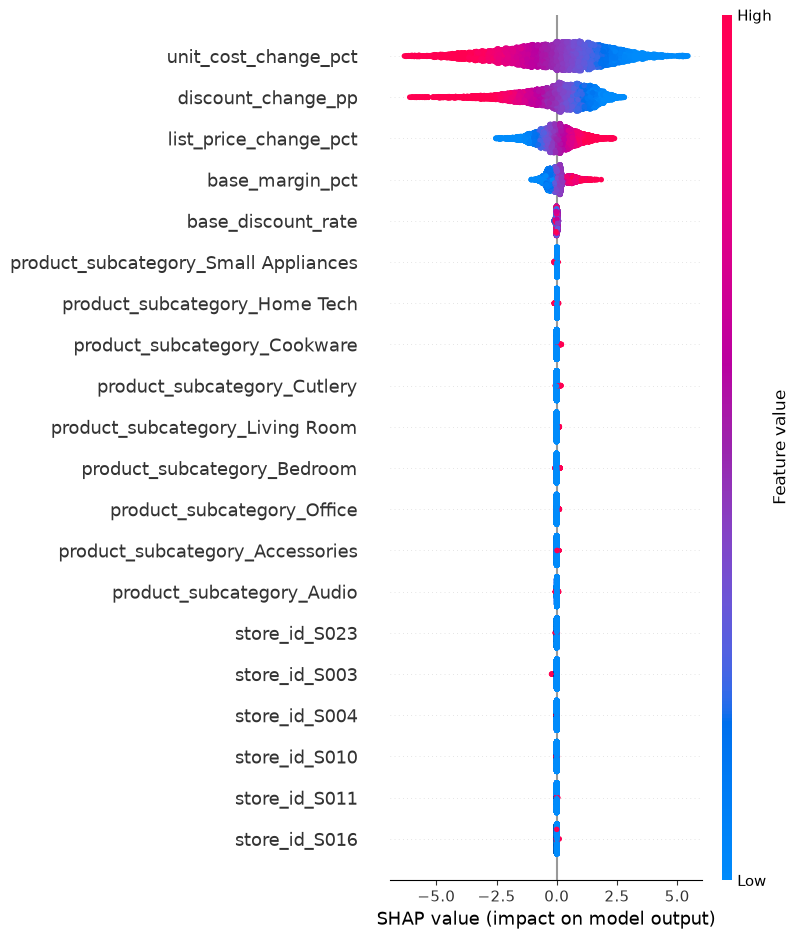

In [37]:
# Which features show the strongest relationships with margin change?
# SHAP explainability

# Best tuned XGBoost pipeline
best_xgb = xgb_search.best_estimator_


# Extract fitted preprocessing + model
preprocessor = best_xgb.named_steps['preprocessor']
xgb_model = best_xgb.named_steps['model']


# Extract one-hot encoded feature names safely from the preprocessor
ohe_cols = list(preprocessor.named_transformers_['cat'].get_feature_names_out(cat_features))
feature_names = ohe_cols + num_features


# Transform the x_test
x_test_transformed = preprocessor.transform(x_test)


# Calculate SHAP values
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(x_test_transformed)

# Plot SHAP summary

shap.summary_plot(shap_values.values, x_test_transformed, feature_names=feature_names)

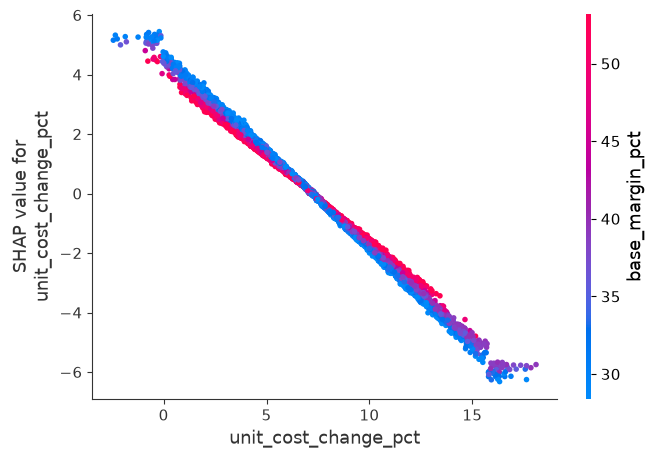

In [38]:
# At what unit_cost threshold does gross margin begin to decrease significantly?
# threshold

shap.dependence_plot('unit_cost_change_pct', shap_values.values, x_test_transformed, feature_names=feature_names)

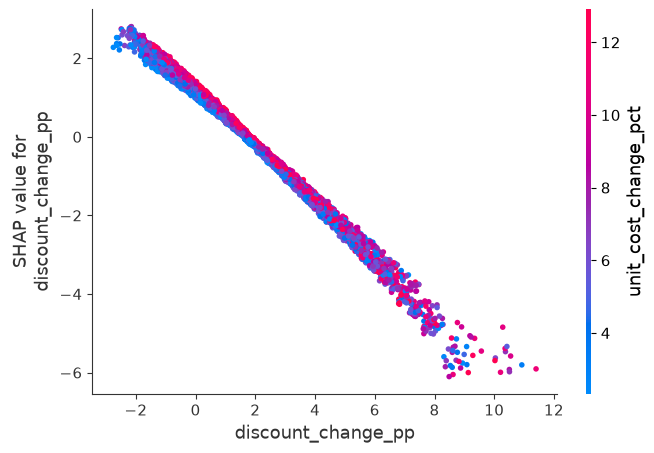

In [39]:
shap.dependence_plot('discount_change_pp', shap_values.values, x_test_transformed, feature_names=feature_names)

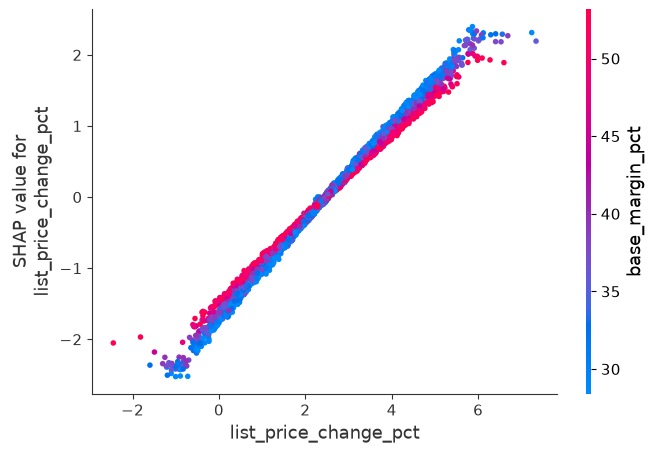

In [40]:
shap.dependence_plot('list_price_change_pct', shap_values.values, x_test_transformed, feature_names=feature_names)

In [41]:
"""
The model found predominantly monotonic, near-linear relationships, rather than strong nonlinear
thresholds. Discount expansion showed some deviation at the extreme end, but not enough to claim
a definitive operating threshold
"""


'\nThe model found predominantly monotonic, near-linear relationships, rather than strong nonlinear\nthresholds. Discount expansion showed some deviation at the extreme end, but not enough to claim\na definitive operating threshold\n'

In [42]:
"""

Recommendations

1. Target cost recovery in Electronics rather than applying broad cost-cutting measures.

The weakest gross-profit performers are heavily concentrated in Electronics. P011 Home Tech 
lost about $18.7k, P004 Accessories $18.4k, P001 Accessories $15.5k, P009 Home Tech $15.3k, 
and P006 Audio $12.4k. In each case, adverse cost effects overwhelmed positive volume and price 
contributions.

Recommendation: 
Prioritize supplier renegotiation, alternative sourcing, and selective cost 
pass-through specifically for the Electronics SKUs generating the largest cost drag.

2. Protect and selectively scale Small Appliances.

P021, P023 and P022 generated approximately +$39.0k, +$34.9k and +$24.3k in gross-profit growth 
respectively. Importantly, their strong positive mix effects — approximately +$41.9k, +$38.5k 
and +$31.9k — helped overcome their own cost increases.

Recommendation: 
Maintain inventory availability and commercial support for these Small Appliance SKUs and 
favour them when allocating incremental sales effort. They are already demonstrating that 
demand growth and favourable mix can absorb cost pressure while still expanding gross profit.


3. Address the adverse mix within specific high-value products — especially Furniture Bedroom.

P027 is particularly interesting. It received a huge +$94.1k volume effect, but suffered 
approximately −$63.4k mix and −$52.2k cost effects, ultimately leaving gross profit about $9.1k 
lower than 2024.

Recommendation: 
Review P027's commercial positioning before pursuing further volume. The issue isn't lack of 
demand, we are already getting volume. Management needs to improve the economics of that growth 
through cost recovery and/or redirect incremental demand toward more profitable Furniture SKUs.

4. Tighten discount governance, but don't invent a universal threshold.

ML work supports discount expansion as an important margin-deterioration variable, 
while the conclusion is that the relationships are predominantly monotonic/near-linear rather 
than showing a robust universal nonlinear threshold.

Recommendation: 
Introduce SKU-level margin floors for discount decisions. Instead of saying “never discount 
more than X%,” require discounts to preserve a minimum expected gross margin after considering 
the SKU's current unit cost.


Overarching recommendation:

Shift the commercial objective from volume growth to profitable volume growth. Prioritize cost 
recovery in underperforming Electronics SKUs, protect the favourable mix momentum in Small 
Appliances, and apply margin-based discount controls to prevent incremental sales from diluting 
gross-margin quality.
"""

"\n\nRecommendations\n\n1. Target cost recovery in Electronics rather than applying broad cost-cutting measures.\n\nThe weakest gross-profit performers are heavily concentrated in Electronics. P011 Home Tech \nlost about $18.7k, P004 Accessories $18.4k, P001 Accessories $15.5k, P009 Home Tech $15.3k, \nand P006 Audio $12.4k. In each case, adverse cost effects overwhelmed positive volume and price \ncontributions.\n\nRecommendation: \nPrioritize supplier renegotiation, alternative sourcing, and selective cost \npass-through specifically for the Electronics SKUs generating the largest cost drag.\n\n2. Protect and selectively scale Small Appliances.\n\nP021, P023 and P022 generated approximately +$39.0k, +$34.9k and +$24.3k in gross-profit growth \nrespectively. Importantly, their strong positive mix effects — approximately +$41.9k, +$38.5k \nand +$31.9k — helped overcome their own cost increases.\n\nRecommendation: \nMaintain inventory availability and commercial support for these Small 